# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Raihan Putra Syarif Hidayatulloh
- **Email:** raiham.rp@gmail.com
- **ID Dicoding:** raihan_putra_syarif_hidayatulloh_k7iu

## Menentukan Pertanyaan Bisnis

- Bagaimana pola rata-rata jumlah penyewaan sepeda per jam dalam sehari, serta perbedaan rata-rata penyewaan antara hari kerja dan hari libur selama periode tahun 2011–2012?
- Seberapa besar pengaruh kondisi cuaca dan faktor lingkungan terhadap rata-rata jumlah penyewaan sepeda, serta bagaimana perubahan tersebut dapat digunakan untuk mengoptimalkan strategi operasional selama periode 2011–2012?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

**Insight:**
- dataset terdiri dari 2 file yaitu day.scv yang memiliki 731 data harian dan pada file hour.csv memiliki 17.379 data perjam. dari data yang ada dapat di analisis dengan baik secara makro atau mikro karena memiliki data harian dan perjam. kedua data ini memiliki sturktur kolom yang hampir sama hanya berbeda ada tambahan kolom hr pada data perjam.
- dataset ini memiliki berbagai variabel penting seperti waktu, kondisi hari, cuaca, dan tipe pengguna, dengan cnt sebagai target utama (jumlah penyewaan). pada tipe data secara keseluruhan sudah sesuai hanya saja pada kolom dteday masih bertipe object sehingga perlu diubah menjadi datetime agar mendukung analisis waktu.

### Assessing Data

In [3]:
day_df.info()
hour_df.info()

# cek missing
day_df.isnull().sum()
hour_df.isnull().sum()

# cek duplicated
day_df.duplicated().sum()
hour_df.duplicated().sum()

day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- pada kualitas data yang didapat ini sudah baik karena dataset tidak memilki missing value atau duplikat sehingga data ini sudah masuk ke dalam kategori  baik dan bersih. tetapi pada kolom dteday masih bertipe object sehingga perlu diubah menjadi datetime agar mendukung analisis waktu. selain itu terdapat beberapa kolom seperti season, weathersit, weekday dan working day masih berupa angka sehingga perlu adanya mapping agar lebih mudah dipahami.
- berdasarkan statistik deskripstif yang di dapat tidak di temukan outlier yang ekstrem dan masih dalam rentang yang wajar yaitu 22-8714. selain itu mayorias pengguna sepeda ini di dominasi oleh pengguna yang sudah terdaftar atau yang rutin dibandingkan dengan pengguna kasual.

### Cleaning Data

In [4]:
day_clean = day_df.copy()
hour_clean = hour_df.copy()

# covert tipe data dteday
day_clean['dteday'] = pd.to_datetime(day_clean['dteday'])
hour_clean['dteday'] = pd.to_datetime(hour_clean['dteday'])

# rename
day_clean.rename(columns={'cnt': 'total_rentals'}, inplace=True)
hour_clean.rename(columns={'cnt': 'total_rentals'}, inplace=True)

# mapping kategori

# season
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

# weather
weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

# apply mapping
day_clean['season_label'] = day_clean['season'].map(season_map)
hour_clean['season_label'] = hour_clean['season'].map(season_map)

day_clean['weather_label'] = day_clean['weathersit'].map(weather_map)
hour_clean['weather_label'] = hour_clean['weathersit'].map(weather_map)

# cek hasil
day_clean.info()
hour_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   instant        731 non-null    int64         
 1   dteday         731 non-null    datetime64[ns]
 2   season         731 non-null    int64         
 3   yr             731 non-null    int64         
 4   mnth           731 non-null    int64         
 5   holiday        731 non-null    int64         
 6   weekday        731 non-null    int64         
 7   workingday     731 non-null    int64         
 8   weathersit     731 non-null    int64         
 9   temp           731 non-null    float64       
 10  atemp          731 non-null    float64       
 11  hum            731 non-null    float64       
 12  windspeed      731 non-null    float64       
 13  casual         731 non-null    int64         
 14  registered     731 non-null    int64         
 15  total_rentals  731 non-

**Insight:**
- perbaikan struktur dan data telah dilakukan untuk hasil yang di dapat yaitu kolom dteday telah di convert menjadi datetime, pada kolom cnt diubah menjadi total_rentals supaya menjadi lebih jelas dan ada penambahan kolom season_label dan weather_label untuk membuat data lebih mudah dipahami dan untuk visualisasi data.
- pada proses cleaning data ini tidak terdapat missing value atau duplikat dan tipe data sudah sesuai dengan kebutuhan analisis sehingga struktur data lebih informatif dan siap untuk ke tahap analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore Pola Waktu, Hari, dan Cuaca terhadap Penyewaan Sepeda

=== Pola per Jam ===


,hr,total_rentals
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


=== Working Day vs Holiday ===


,workingday,total_rentals
0,0,4330.168831
1,1,4584.820000


=== Pengaruh Cuaca ===


...

,temp,hum,windspeed,total_rentals
temp,1.000000,0.126963,-0.157944,0.627494
hum,0.126963,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.248489,1.000000,-0.234545
total_rentals,0.627494,-0.100659,-0.234545,1.000000


=== Musim ===


,season_label,total_rentals
0,Fall,5644.303191
1,Spring,2604.132597
2,Summer,4992.331522
3,Winter,4728.162921


=== Bulanan ===


,mnth,total_rentals
0,1,2176.338710
1,2,2655.298246
2,3,3692.258065
3,4,4484.900000
4,5,5349.774194
5,6,5772.366667
6,7,5563.677419
7,8,5664.419355
8,9,5766.516667
9,10,5199.225806


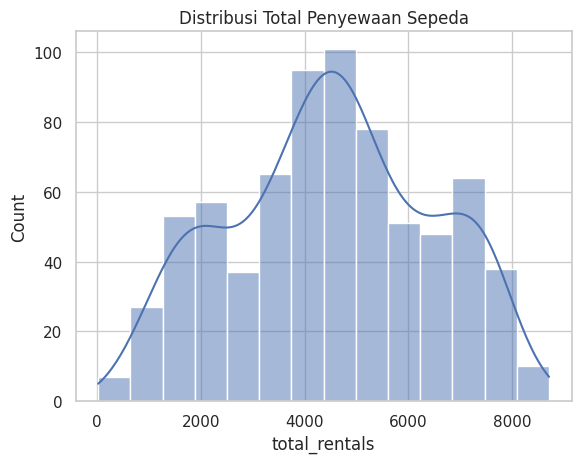

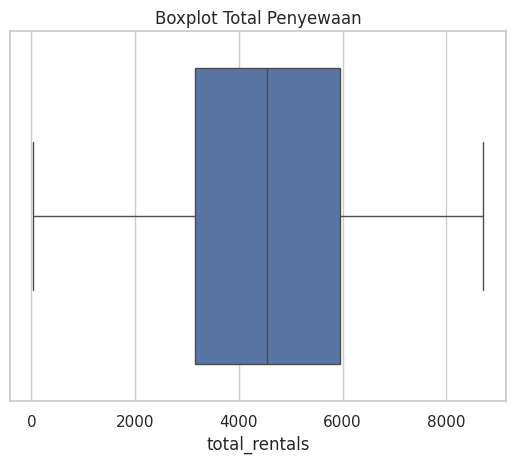

In [13]:


# pola rata-rata per jam
hourly_usage = hour_clean.groupby('hr')['total_rentals'].mean().reset_index()

# pola berdasarkan working day
workingday_usage = day_clean.groupby('workingday')['total_rentals'].mean().reset_index()

# pengaruh cuaca
weather_usage = day_clean.groupby('weather_label')['total_rentals'].mean().reset_index()

# korelasi antar variabel
correlation = day_clean[['temp','hum','windspeed','total_rentals']].corr()

season_usage = day_clean.groupby('season_label')['total_rentals'].mean().reset_index()
monthly_usage = day_clean.groupby('mnth')['total_rentals'].mean().reset_index()


print("=== Pola per Jam ===")
display(hourly_usage)

print("=== Working Day vs Holiday ===")
display(workingday_usage)

print("=== Pengaruh Cuaca ===")
display(weather_usage)

print("=== Korelasi ===")
display(correlation)

print("=== Musim ===")
display(season_usage)

print("=== Bulanan ===")
display(monthly_usage)

sns.histplot(day_clean['total_rentals'], kde=True)
plt.title("Distribusi Total Penyewaan Sepeda")
plt.show()

sns.boxplot(x=day_clean['total_rentals'])
plt.title("Boxplot Total Penyewaan")
plt.show()

**Insight:**
- pola penyewaan dipengaruhi oleh waktu dan jenis hari.
  - Terendah terjadi pada dini hari:
  Jam 04.00 = 6.35 rental, 03.00 = 11.73 rental, 02.00 = 22.87 rental

  - Mulai meningkat pagi hari:
  Jam 06.00 = 76.04, lalu naik tajam
  Jam 07.00 = 212.06, 08.00 = 359.01 (lonjakan besar)

  - Puncak utama terjadi sore hari:
  Jam 17.00 = 461.45 (tertinggi)
  Jam 18.00 = 425.51, 16.00 = 311.98

  - Setelah itu menurun kembali:
  Jam 20.00 = 226.03, 23.00 = 87.83
  
  dari data yang ditampilkan terlihat bahwa jumlah penyewaan sangat fluktuatif sepanjang hari dengan puncak pada jam sibuk (pagi dan sore), serta lebih tinggi pada hari kerja dibandingkan hari libur. Hal ini menunjukkan bahwa penggunaan sepeda cenderung bersifat rutin untuk kebutuhan aktivitas seperti untuk bekerja maupun bersekolah.

- faktor cuaca dan lingkungan mempengaruhi penyewaan sepeda karena berdasarkan pengelompokan dan analisis korelasi kondisi cuaca dan elemen lingkungan seperti suhu, kelembapan, dan kecepatan angin dikaitkan dengan jumlah penyewaan sepeda, menunjukkan bahwa kenyamanan lingkungan merupakan faktor penting dalam tingkat penggunaan sepeda. berikut hasil analisis yang dihasilkan:
  - Cuaca (weather):

      Clear (cerah): 4876.79 rental (tertinggi)
      Mist (berkabut): 4035.86 rental
      Light Rain/Snow: 1803.29 rental (menurun drastis)

  - Korelasi faktor lingkungan:

      Temperature (temp): +0.627 → pengaruh positif kuat (semakin hangat, semakin banyak penyewaan rental),
      Humidity (hum): -0.100 → pengaruh negatif lemah,
      Windspeed: -0.234 → pengaruh negatif sedang

  - Musim (season):

      Fall: 5644.30 (tertinggi),
      Summer: 4992.33,
      Winter: 4728.16,
      Spring: 2604.13 (terendah)

## Visualization & Explanatory Analysis

### Pertanyaan 1:

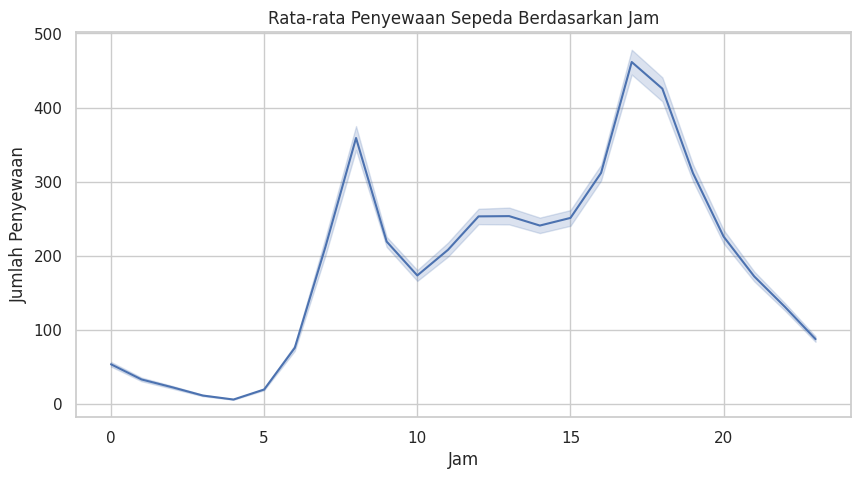

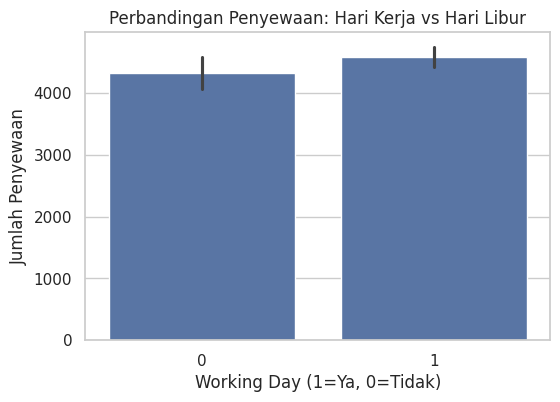

In [6]:
plt.figure(figsize=(10,5))
sns.lineplot(data=hour_clean, x='hr', y='total_rentals', estimator='mean')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=day_clean, x='workingday', y='total_rentals')
plt.title('Perbandingan Penyewaan: Hari Kerja vs Hari Libur')
plt.xlabel('Working Day (1=Ya, 0=Tidak)')
plt.ylabel('Jumlah Penyewaan')
plt.show()

### Pertanyaan 2:

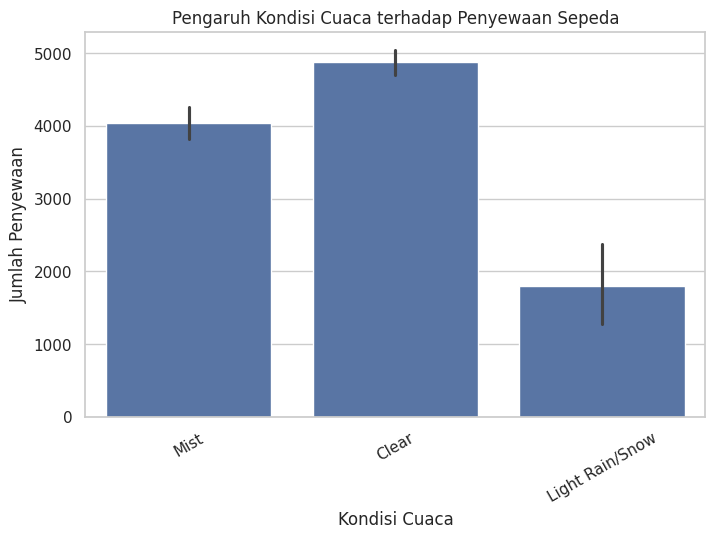

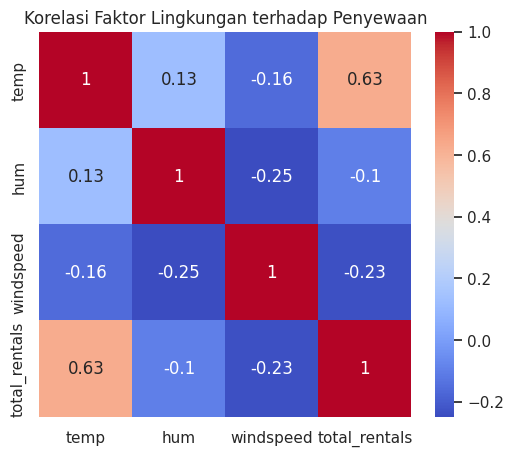

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_clean, x='weather_label', y='total_rentals')
plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(day_clean[['temp','hum','windspeed','total_rentals']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Korelasi Faktor Lingkungan terhadap Penyewaan')
plt.show()

**Insight:**
- Visualisasi pertanyaan 1: Dari hasil visualisasi yang didapat, penyewaan sepeda sangat rendah pada waktu dini hari, yaitu sekitar pada pukul 00.00 sebesar 53.90 rental, kemudian terus menurun hingga titik terendah di jam 04.00 hanya 6.35 rental. Setelah itu mulai meningkat tajam pada pagi hari, terutama pada jam sibuk kerja, yaitu jam 07.00 = 212.06 rental dan mencapai puncak pagi di jam 08.00 = 359.01 rental.

  Pada sore hari terjadi lonjakan tertinggi, yaitu pada pukul 17.00 mencapai 461.45 rental (tertinggi secara keseluruhan), diikuti jam 18.00 = 425.51 rental. Setelah jam tersebut, jumlah penyewaan kembali menurun hingga malam hari, seperti jam 23.00 hanya 87.83 rental.

  Selain itu, berdasarkan perbandingan hari kerja dan hari libur, jumlah penyewaan pada hari kerja mencapai 4584.82 rental, lebih tinggi dibandingkan hari libur yaitu 4330.17 rental. Hal ini menunjukkan bahwa mayoritas penggunaan sepeda digunakan untuk aktivitas rutin seperti bekerja atau sekolah.

- Visualisasi pertanyaan 2: Dari hasil visualisasi yang didapat, kondisi cuaca sangat mempengaruhi jumlah penyewaan sepeda. Pada kondisi cuaca cerah (clear) jumlah penyewaan mencapai 4876.79 rental (tertinggi), kemudian menurun pada kondisi berkabut (mist) yaitu 4035.86 rental, dan turun cukup signifikan pada kondisi buruk seperti hujan atau salju ringan (light rain/snow) yaitu hanya 1803.29 rental (turun sekitar 60% dibanding cuaca cerah).

  Selain itu, dari hasil heatmap korelasi, temperatur (temp) memiliki pengaruh paling kuat terhadap jumlah penyewaan dengan nilai korelasi +0.63, yang menunjukkan hubungan positif yang cukup kuat. Sementara itu, kelembapan (humidity) memiliki korelasi -0.1, dan kecepatan angin (windspeed) sebesar -0.23, yang menunjukkan pengaruh negatif namun relatif lebih lemah dibanding temperatur.

  Hal ini menandakan bahwa semakin tinggi suhu atau cuaca yang lebih hangat, jumlah penyewaan meningkat, sedangkan kondisi lembab dan angin kencang cenderung sedikit menurunkan jumlah penyewaan sepeda.

## Analisis Lanjutan (Opsional)

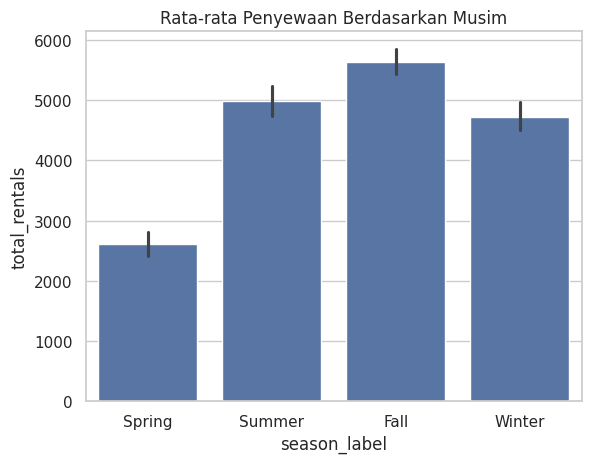

In [8]:
# rata-rata penyewaan musim
sns.barplot(x='season_label', y='total_rentals', data=day_clean)
plt.title("Rata-rata Penyewaan Berdasarkan Musim")
plt.show()

## Conclusion

- Conclution pertanyaan 1: Pola penyewaan sepeda sangat dipengaruhi oleh waktu dan jenis hari. Berdasarkan data, jumlah penyewaan menunjukkan pola yang sangat jelas dengan nilai terendah pada dini hari, yaitu sekitar 6–53 rental, kemudian mulai meningkat pada pagi hari dan mencapai lonjakan signifikan pada jam sibuk 07.00–09.00 dengan puncak sekitar 359 rental pada jam 08.00.

  Peningkatan kembali terjadi pada sore hari dan mencapai titik tertinggi pada jam 17.00 sebesar 461.45 rental, diikuti jam 18.00 sebesar 425.51 rental. Secara keseluruhan, tren ini menunjukkan pola commuting, di mana pengguna lebih banyak menggunakan sepeda untuk aktivitas rutin seperti bekerja atau sekolah.

  Selain itu, rata-rata penyewaan pada hari kerja sebesar 4584.82 rental, lebih tinggi dibandingkan hari libur yaitu 4330.17 rental. Hal ini memperkuat bahwa penggunaan sepeda lebih dominan untuk kebutuhan mobilitas harian dibandingkan rekreasi.

  maka dari itu perlu melakukan optimasi untuk ketersedian sepeda pada jam-jam sibuk yaitu pada jam 07.00-09.00 dan 16.00-18.00, meningkatkan sistem dan untuk melakukan maintenance pada jam yang tidak sibuk yaitu pada dini hari atau malam hari, selain itu perlu memerlukan program langganan untuk pekerja atau pelajar karena melihat dari pola yang didapat pola penggunaan ini bersifat rutin.

- Conclution pertanyaan 2: Pengaruh cuaca dan faktor lingkungan terbukti sangat memengaruhi tingkat penyewaan sepeda. Dari data, kondisi cuaca cerah (clear) menghasilkan rata-rata penyewaan tertinggi yaitu 4876.79 rental, diikuti kondisi berkabut (mist) sebesar 4035.86 rental, sedangkan cuaca buruk (light rain/snow) mengalami penurunan signifikan hingga 1803.29 rental (turun sekitar 60% dari kondisi cerah).

  Dari sisi tren, terlihat bahwa semakin baik kondisi cuaca, semakin tinggi jumlah penyewaan. Hal ini juga didukung oleh korelasi temperatur yang cukup kuat sebesar +0.627, yang menunjukkan bahwa peningkatan suhu cenderung meningkatkan jumlah penyewaan. Sebaliknya, kelembapan (-0.100) dan kecepatan angin (-0.234) memberikan dampak negatif terhadap permintaan.

  Selain itu, faktor musim juga menunjukkan perbedaan yang jelas, dengan penyewaan tertinggi pada musim Fall sebesar 5644.30 rental, dan terendah pada musim Spring sebesar 2604.13 rental. Hal ini menunjukkan bahwa kenyamanan kondisi lingkungan sangat berpengaruh terhadap keputusan pengguna dalam menggunakan sepeda.

  maka dari itu perlu menyediakan diskon atau promosi disaat musim yang kurang peminatnya yaitu pada musim spring yang berguna untuk meningkatkan jumlah pengguna, mengoptimalkan atau  menambah unit pada saat peminatnya tinggi yaitu pada musim fall atau summer, menyediakan fasilitas tambahan seperti jas hujan atau rain cover yang berguna untuk digunakan cuaca buruk, dan perlu adanya sistem untuk prediksi cuaca untuk manajemen distribusi sepeda.

## Export data

In [14]:
day_clean.to_csv('dashboard/main_data.csv', index=False)
hour_clean.to_csv('dashboard/hour_data.csv', index=False)